# Spherical Harmonics Lighting Tutorial

## Introduction

Welcome to this comprehensive tutorial on **Spherical Harmonics (SH) Lighting**! 

### What You'll Learn:
1. What are SH basis functions and how do they work?
2. How SH coefficients are object-independent
3. How to optimize SH coefficients to match target lighting

### What are Spherical Harmonics?

Spherical Harmonics are mathematical functions defined on the surface of a sphere. Think of them as **Fourier series for spheres**!

- Just like Fourier series can represent any periodic function as a sum of sines and cosines
- SH can represent any function on a sphere as a weighted sum of basis functions
- Lower orders capture low-frequency (smooth) features
- Higher orders capture high-frequency (detailed) features

### Why Use SH for Lighting?

**Advantages:**
- ✅ **Compact**: Only 9 coefficients (Order 2) for good approximation
- ✅ **Fast**: Efficient to evaluate and render
- ✅ **Differentiable**: Can optimize with gradient descent

## Setup: Import Libraries

First, let's import all the necessary libraries for our tutorial.

In [47]:
import os
import torch
import matplotlib.pyplot as plt
import numpy as np
import math

from pytorch3d.structures import Meshes
from pytorch3d.renderer import (
    look_at_view_transform,
    FoVPerspectiveCameras,
    PointLights,
    DirectionalLights,
    Materials,
    RasterizationSettings,
    MeshRenderer,
    MeshRasterizer,
    SoftPhongShader,
    TexturesVertex
)
import torch.nn.functional as F
from pytorch3d.renderer.utils import convert_to_tensors_and_broadcast, TensorProperties
from pytorch3d.renderer.lighting import _validate_light_properties

# Setup device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Create output directory
output_dir = "./sh_tutorial_output"
os.makedirs(output_dir, exist_ok=True)
print(f"Output directory: {output_dir}")

Using device: cuda:0
Output directory: ./sh_tutorial_output


## Part 1: Environment Map Lighting Class

### What is Environment Map Lighting?

Instead of using point or directional lights, **environment map lighting** uses an image (environment map) to define lighting from all directions.

This is what our SH coefficients will be converted into!

### Key Concepts:
- **Diffuse component**: How light scatters off rough surfaces (based on surface normal)
- **Specular component**: How light reflects off shiny surfaces (based on reflection direction)
- **UV mapping**: Converting 3D directions to 2D texture coordinates

In [48]:
class EnvMapLights(TensorProperties):
    """
    Environment Map Lighting
    
    This class samples lighting from an environment map (image) based on:
    - Surface normals (for diffuse lighting)
    - Reflection directions (for specular lighting)
    """
    def __init__(
        self,
        ambient_color=((0., 0., 0.),),
        diffuse_color=((0.8, 0.8, 0.8),),
        specular_color=((0.0, 0.0, 0.0),),
        device="cpu",
    ):
        super().__init__(
            device=device,
            ambient_color=ambient_color,
            diffuse_color=diffuse_color,
            specular_color=specular_color,
        )
        _validate_light_properties(self)

    def clone(self):
        other = self.__class__(device=self.device)
        return super().clone(other)

    def _convert_to_uv(self, directions):
        """Convert 3D directions to 2D UV coordinates for environment map lookup"""
        x2 = directions[..., 0] ** 2
        y2 = directions[..., 1] ** 2
        z2 = (directions[..., 2] + 1) ** 2
        m = 2 * torch.sqrt(x2 + y2 + z2)[..., None]
        uv_directions = directions[..., :2] / m
        uv_directions = uv_directions + 0.5
        uv_directions = uv_directions * 2 - 1
        return uv_directions

    def diffuse(self, normals, points=None):
        """Sample diffuse color from environment map based on surface normal"""
        normals, color = convert_to_tensors_and_broadcast(
            normals, self.diffuse_color, device=normals.device
        )
        points_dims = normals.shape[1:-1]
        expand_dims = (-1,) + (1,) * len(points_dims) + (3,)
        if color.shape != normals.shape:
            if color.dim() == 2 and color.shape[1] == 3:
                color = color.view(expand_dims)
            elif color.dim() == normals.dim() - 1:
                color = color.unsqueeze(-2)
        
        normals = F.normalize(normals, p=2, dim=-1, eps=1e-6)
        uv_normals = self._convert_to_uv(normals)
        
        input_color = color.squeeze(-2).permute(0, 3, 1, 2)
        grid_uv_normals = uv_normals.squeeze(-2)
        sampled_color = F.grid_sample(input_color, grid_uv_normals, 
                                     padding_mode="reflection", align_corners=False)
        color = sampled_color.permute(0, 2, 3, 1).unsqueeze(-2)
        return color

    def specular(self, normals, points, camera_position, shininess):
        """Sample specular color from environment map based on reflection direction"""
        if points.shape != normals.shape:
            raise ValueError(f"Expected points and normals to have same shape")
        
        matched_tensors = convert_to_tensors_and_broadcast(
            points, self.specular_color, camera_position, shininess, device=points.device
        )
        _, color, camera_position, shininess = matched_tensors
        
        points_dims = points.shape[1:-1]
        expand_dims = (-1,) + (1,) * len(points_dims)
        if camera_position.shape != normals.shape:
            camera_position = camera_position.view(expand_dims + (3,))
        if shininess.shape != normals.shape:
            shininess = shininess.view(expand_dims)
        if color.shape != normals.shape:
            if color.dim() == 2 and color.shape[1] == 3:
                color = color.view(expand_dims + (3,))
            elif color.dim() == normals.dim() - 1:
                color = color.unsqueeze(-2)
        
        normals = F.normalize(normals, p=2, dim=-1, eps=1e-6)
        view_direction = camera_position - points
        view_direction = F.normalize(view_direction, p=2, dim=-1, eps=1e-6)
        
        cos_angle = torch.sum(normals * view_direction, dim=-1)
        mask = (cos_angle > 0).to(torch.float32)
        
        reflect_direction = -view_direction + 2 * (cos_angle[..., None] * normals)
        reflect_direction = F.normalize(reflect_direction, dim=-1)
        
        uv_reflect_direction = self._convert_to_uv(reflect_direction)
        input_color = color.squeeze(-2).permute(0, 3, 1, 2)
        grid_uv_reflect_direction = uv_reflect_direction.squeeze(-2)
        
        sampled_color = F.grid_sample(input_color, grid_uv_reflect_direction,
                                     padding_mode="reflection", align_corners=False)
        color = sampled_color.permute(0, 2, 3, 1).unsqueeze(-2)
        
        alpha = F.relu(torch.sum(view_direction * reflect_direction, dim=-1)) * mask
        return color * torch.pow(alpha, shininess)[..., None]

print("✓ EnvMapLights class defined")

✓ EnvMapLights class defined


## Part 2: Spherical Harmonics Implementation

### The Math Behind SH

Spherical harmonics $Y_l^m(\theta, \phi)$ are defined by:
- **Order** $l$: Controls frequency (0 = constant, 1 = linear, 2 = quadratic, etc.)
- **Degree** $m$: Ranges from $-l$ to $+l$
- **Total coefficients**: $(l+1)^2$ for order $l$

For example:
- Order 0: 1 coefficient (constant/ambient)
- Order 1: 4 coefficients (linear gradients)
- Order 2: 9 coefficients (quadratic patterns)
- Order 3: 16 coefficients

### Key Operations:
1. **Evaluate basis function**: Compute $Y_l^m(\theta, \phi)$ at given angles
2. **Reconstruct function**: Sum weighted basis functions to get environment map

In [ ]:
class SphericalHarmonics:
    """
    Spherical Harmonics Implementation
    
    This class provides methods to:
    1. Evaluate SH basis functions Y_l^m(theta, phi)
    2. Convert SH coefficients to environment maps
    """
    def __init__(self, env_map_resolution, device):
        self.device = device
        self.set_environment_map_resolution(env_map_resolution)

    def set_environment_map_resolution(self, res):
        """Setup the spherical coordinate grid for environment map"""
        res = (res, res)
        self.resolution = res
        uv = np.mgrid[0:res[1], 0:res[0]].astype(np.float32)
        # Theta: polar angle [0, pi]
        self.theta = torch.from_numpy((math.pi / res[1]) * (uv[1, :, :] + 0.5)).to(self.device)
        # Phi: azimuthal angle [0, 2*pi]
        self.phi = torch.from_numpy((2 * math.pi / res[0]) * (uv[0, :, :] + 0.5)).to(self.device)

    def compute_associated_legendre_polynomial(self, l, m, x):
        """Compute associated Legendre polynomial P_l^m(x)"""
        pmm = torch.ones_like(x)
        if m > 0:
            somx2 = torch.sqrt((1 - x) * (1 + x))
            fact = 1.0
            for i in range(1, m + 1):
                pmm = pmm * (-fact) * somx2
                fact += 2.0
        if l == m:
            return pmm
        
        pmmp1 = x * (2.0 * m + 1.0) * pmm
        if l == m + 1:
            return pmmp1
        
        pll = torch.zeros_like(x)
        for ll in range(m + 2, l + 1):
            pll = ((2.0 * ll - 1.0) * x * pmmp1 - (ll + m - 1.0) * pmm) / (ll - m)
            pmm = pmmp1
            pmmp1 = pll
        return pll

    def compute_normalization_factor(self, l, m):
        """Compute normalization factor for orthonormality"""
        numerator = (2.0 * l + 1.0) * math.factorial(l - m)
        denominator = 4 * math.pi * math.factorial(l + m)
        return math.sqrt(numerator / denominator)

    def evaluate_spherical_harmonic(self, l, m, theta, phi):
        """Evaluate spherical harmonic Y_l^m at given angles"""
        if m == 0:
            return self.compute_normalization_factor(l, m) * \
                   self.compute_associated_legendre_polynomial(l, m, torch.cos(theta))
        elif m > 0:
            return math.sqrt(2.0) * self.compute_normalization_factor(l, m) * \
                   torch.cos(m * phi) * self.compute_associated_legendre_polynomial(l, m, torch.cos(theta))
        else:
            return math.sqrt(2.0) * self.compute_normalization_factor(l, -m) * \
                   torch.sin(-m * phi) * self.compute_associated_legendre_polynomial(l, -m, torch.cos(theta))

    def convert_sh_to_environment_map(self, sh_coeffs):
        """        
        This is the KEY operation: taking compact SH coefficients and
        reconstructing the full environment map!
        
        Args:
            sh_coeffs: [batch, num_coeffs, 3] tensor of SH coefficients
        Returns:
            env_maps: [batch, height, width, 3] environment maps
        """
        assert(sh_coeffs.dim() == 3 and sh_coeffs.shape[-1] == 3)
        env_maps = torch.zeros([sh_coeffs.shape[0], self.resolution[0], 
                               self.resolution[1], 3]).to(sh_coeffs.device)
        for i in range(sh_coeffs.shape[0]):
            env_map = self.construct_environment_map_from_sh_coeffs(sh_coeffs[i])
            env_maps[i] = env_map
        return env_maps

    def _get_basis_stack(self, num_coeffs):
        """Evaluate the SH basis maps once and cache them: [num_coeffs, H, W]."""
        cached = getattr(self, "_basis_stack", None)
        if cached is not None and cached.shape[0] == num_coeffs:
            return cached
        bands = int(math.sqrt(num_coeffs))
        with torch.no_grad():
            maps = [self.evaluate_spherical_harmonic(l, m, self.theta, self.phi)
                    for l in range(bands)
                    for m in range(-l, l + 1)]
            self._basis_stack = torch.stack(maps, dim=0)
        return self._basis_stack
    
    def construct_environment_map_from_sh_coeffs(self, sh_coeffs):
        """Reconstruct environment map from SH coefficients: [C, 3] -> [H, W, 3]"""
        assert (isinstance(sh_coeffs, torch.Tensor)
                and sh_coeffs.dim() == 2 and sh_coeffs.shape[1] == 3)
        bases = self._get_basis_stack(sh_coeffs.shape[0])
        result = torch.einsum('chw,cr->hwr', bases, sh_coeffs)
        return torch.clamp(result, min=0.0)

print("✓ SphericalHarmonics class defined")

✓ SphericalHarmonics class defined


## Step 2: Create Test Object


In [50]:
print("Creating test object...")

def create_bumpy_mesh(radius=1.0, subdivisions=80, device="cpu"):
    """Create a complex bumpy mesh with varied normals by displacing a sphere
    with multiple frequency perturbations."""
    u = torch.linspace(0, 2 * np.pi, subdivisions)
    v = torch.linspace(0, np.pi, subdivisions)
    u, v = torch.meshgrid(u, v, indexing='ij')

    # Multi-frequency radial displacement to create complex surface normals
    bump = (
        0.15 * torch.sin(3 * u) * torch.sin(2 * v)
        + 0.10 * torch.sin(5 * u) * torch.cos(3 * v)
        + 0.08 * torch.cos(4 * u) * torch.sin(5 * v)
        + 0.06 * torch.sin(7 * u + 2 * v)
        + 0.05 * torch.cos(2 * u - 5 * v)
    )
    r = radius + bump

    x = r * torch.sin(v) * torch.cos(u)
    y = r * torch.sin(v) * torch.sin(u)
    z = r * torch.cos(v)

    verts = torch.stack([x.flatten(), y.flatten(), z.flatten()], dim=1)

    faces = []
    for i in range(subdivisions - 1):
        for j in range(subdivisions - 1):
            v0 = i * subdivisions + j
            v1 = v0 + 1
            v2 = v0 + subdivisions
            v3 = v2 + 1
            faces.append([v0, v2, v1])
            faces.append([v1, v2, v3])

    faces = torch.tensor(faces, dtype=torch.int64)
    verts_rgb = torch.ones_like(verts)
    textures = TexturesVertex(verts_features=[verts_rgb])

    return Meshes(verts=[verts], faces=[faces], textures=textures).to(device)

print("✓ Mesh creation functions defined")

bumpy_mesh = create_bumpy_mesh(radius=1.0, subdivisions=80, device=device)


Creating test object...
✓ Mesh creation functions defined


## Step 3: Create Target Images with PointLight

### Why PointLight?

PointLight is a great test case for SH because:
- ✅ Positional light source (like a lamp)
- ✅ Smooth lighting gradients across surfaces
- ✅ No sharp shadows or hotspots
- ✅ Low-order SH can represent it well

We'll render our bumpy mesh from 10 different viewpoints with PointLight. These will be our **target images** that we try to match with SH.

Rendering target images with PointLight...


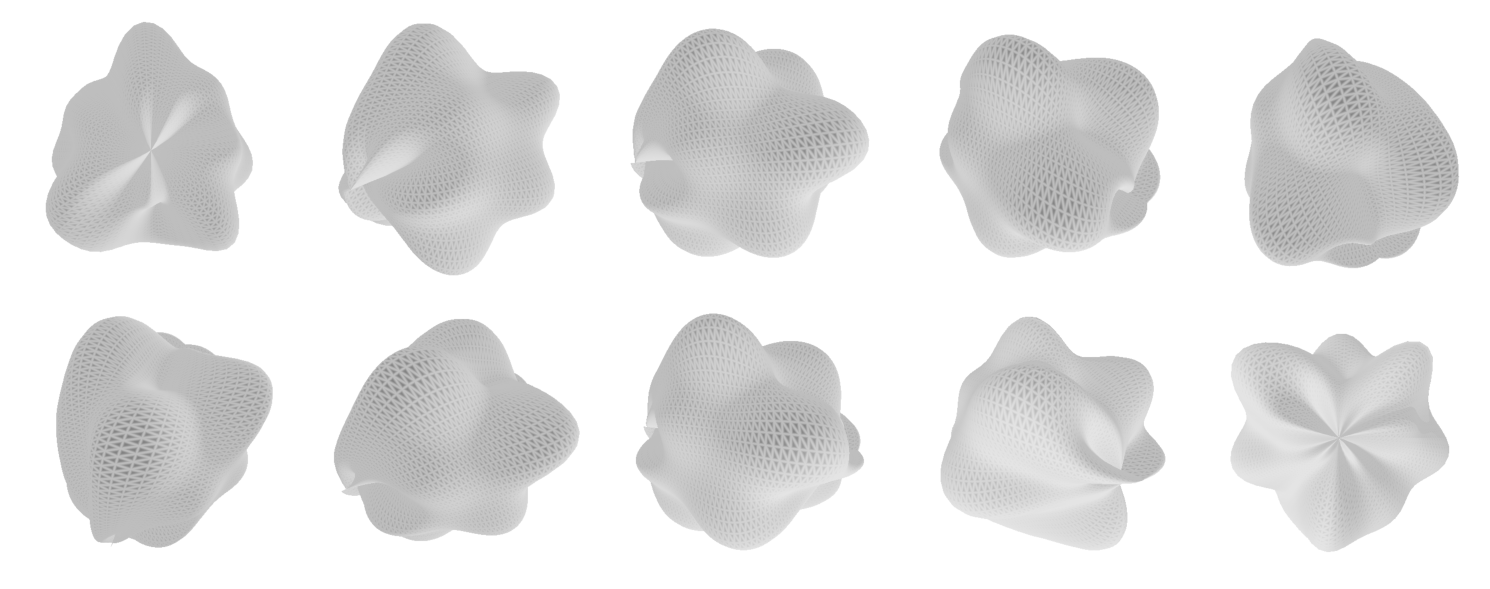

✓ Rendered 10 views with PointLight
  Saved to: ./sh_tutorial_output/target_pointlight.png


In [51]:
# Setup renderer
batch_size = 10
mesh = bumpy_mesh 
meshes = mesh.extend(batch_size)

# Create camera positions (10 different viewpoints)
elev = torch.linspace(0, 180, batch_size)
azim = torch.linspace(-180, 180, batch_size)
R, T = look_at_view_transform(dist=2.7, elev=elev, azim=azim)
cameras = FoVPerspectiveCameras(device=device, R=R, T=T)

# Rasterization settings
raster_settings = RasterizationSettings(image_size=512, blur_radius=0, faces_per_pixel=1)

# Create renderer
renderer = MeshRenderer(
    rasterizer=MeshRasterizer(cameras=cameras, raster_settings=raster_settings),
    shader=SoftPhongShader(device=device, cameras=cameras)
)

# Create PointLight (matching reference tutorial)
point_lights = PointLights(device=device)
point_lights.location = torch.tensor([[2.0, 2.0, -2.0]], device=device)

# Material properties
materials = Materials(device=device, specular_color=[[1.0, 1.0, 1.0]], shininess=10.0)

# Render target images
print("Rendering target images with PointLight...")
target_images = renderer(meshes, lights=point_lights, materials=materials, cameras=cameras)

# Save target images
def save_image_grid(images, output_path, rows=2, cols=5):
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    axes = axes.flatten()
    for i, (ax, img) in enumerate(zip(axes, images)):
        ax.imshow(img)
        ax.axis('off')
    for i in range(len(images), len(axes)):
        axes[i].axis('off')
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.show()

save_image_grid(target_images.cpu().numpy(), 
               os.path.join(output_dir, "target_pointlight.png"), rows=2, cols=5)

print(f"✓ Rendered {batch_size} views with PointLight")
print(f"  Saved to: {output_dir}/target_pointlight.png")

## Step 4: Optimize SH Coefficients

### Inverse Rendering!

Now we'll **optimize SH coefficients** to match the PointLight rendering. This is called **inverse rendering** - recovering lighting from images!

### What We're Optimizing:
- **9 diffuse coefficients** (Order 2 SH) × 3 color channels = 27 parameters
- **9 specular coefficients** (Order 2 SH) × 3 color channels = 27 parameters
- **Total: 54 parameters** to represent all the lighting!

### The Process:
1. Initialize SH coefficients randomly
2. Convert coefficients → environment maps
3. Render with environment maps
4. Compare to target images (compute loss)
5. Backpropagate gradients
6. Update coefficients
7. Repeat!

In [ ]:
# Create the SH helper that converts coefficients into environment maps.
# The resolution only sets the sampling grid: order 2 SH is band-limited,
# so 64 is ample and the renderer interpolates when it samples the map.
sh = SphericalHarmonics(64, device)

# Initialize SH coefficients (Order 2 = 9 coefficients)
# Seed only the order-0 (ambient) term and leave the higher-order bands at
# zero, so optimisation starts from flat, uniform lighting and adds
# directional structure as the loss demands it.
sh_coeffs = 9
diffuse_sh_coefs = torch.zeros((1, sh_coeffs, 3), device=device)
diffuse_sh_coefs[:, 0, :] = 1.772
diffuse_sh_coefs.requires_grad = True

specular_sh_coefs = torch.zeros((1, sh_coeffs, 3), device=device)
specular_sh_coefs[:, 0, :] = 1.772
specular_sh_coefs.requires_grad = True

# Setup optimizer
learning_rate = 0.02
num_iters = 300
optimizer = torch.optim.Adam([diffuse_sh_coefs, specular_sh_coefs], lr=learning_rate)
loss_fn = torch.nn.MSELoss()

print(f"Training for {num_iters} iterations...")
print("(Printing every 50 iterations)\n")

# Training loop
for iter in range(num_iters + 1):
    optimizer.zero_grad()
    
    # Convert SH coefficients to environment maps
    diffuse_envmap = sh.convert_sh_to_environment_map(diffuse_sh_coefs).clip(0, 1)
    specular_envmap = sh.convert_sh_to_environment_map(specular_sh_coefs).clip(0, 1)
    
    # Render with SH lighting
    pred_images = renderer(meshes, 
                          lights=EnvMapLights(diffuse_color=diffuse_envmap,
                                             specular_color=specular_envmap,
                                             device=device), 
                          materials=materials, 
                          cameras=cameras)
    
    # Compute loss
    loss = loss_fn(pred_images, target_images)
    
    # Backpropagation
    loss.backward()
    optimizer.step()
    
    # Print progress
    if iter % 50 == 0:
        print(f'Iteration {iter:3d}/{num_iters} | Loss: {loss.item():.6f}')
        print(f'  Diffuse  - Mean: {diffuse_sh_coefs.mean().item():6.3f}, ' +
              f'Std: {diffuse_sh_coefs.std().item():.3f}, ' +
              f'Range: [{diffuse_sh_coefs.min().item():6.3f}, {diffuse_sh_coefs.max().item():6.3f}]')
        print(f'  Specular - Mean: {specular_sh_coefs.mean().item():6.3f}, ' +
              f'Std: {specular_sh_coefs.std().item():.3f}, ' +
              f'Range: [{specular_sh_coefs.min().item():6.3f}, {specular_sh_coefs.max().item():6.3f}]')
        print()

print("✓ Optimization complete!")

Training for 300 iterations...
(Printing every 50 iterations)

Iteration   0/300 | Loss: 0.116760
  Diffuse  - Mean:  0.002, Std: 0.020, Range: [-0.020,  0.020]
  Specular - Mean: -0.002, Std: 0.018, Range: [-0.019,  0.019]

Iteration  50/300 | Loss: 0.017932
  Diffuse  - Mean:  0.065, Std: 0.473, Range: [-0.576,  0.798]
  Specular - Mean: -0.063, Std: 0.614, Range: [-0.638,  0.638]

Iteration 100/300 | Loss: 0.011380
  Diffuse  - Mean:  0.105, Std: 0.447, Range: [-0.519,  0.954]
  Specular - Mean: -0.069, Std: 0.664, Range: [-0.728,  0.720]

Iteration 150/300 | Loss: 0.005246
  Diffuse  - Mean:  0.158, Std: 0.501, Range: [-0.516,  1.343]
  Specular - Mean: -0.074, Std: 0.686, Range: [-0.749,  0.784]

Iteration 200/300 | Loss: 0.002450
  Diffuse  - Mean:  0.163, Std: 0.556, Range: [-0.317,  1.624]
  Specular - Mean: -0.080, Std: 0.704, Range: [-0.755,  0.843]

Iteration 250/300 | Loss: 0.001042
  Diffuse  - Mean:  0.182, Std: 0.603, Range: [-0.221,  1.822]
  Specular - Mean: -0.082, St

## Step 5: Visualize Learned Environment Maps

Let's see what environment maps our optimized SH coefficients produce!

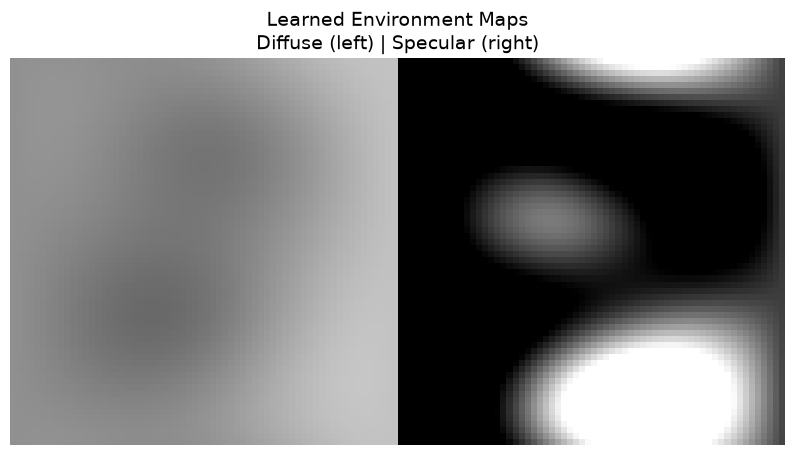

✓ Saved environment maps to: ./sh_tutorial_output/learned_environment_maps.png


In [53]:
# Save environment maps
envmap_combined = torch.cat([diffuse_envmap, specular_envmap], dim=-2).squeeze().permute(2, 0, 1)

plt.figure(figsize=(10, 10))
plt.imshow(envmap_combined.detach().cpu().numpy().transpose(1, 2, 0))
plt.axis("off")
plt.title("Learned Environment Maps\nDiffuse (left) | Specular (right)", fontsize=14)
plt.savefig(os.path.join(output_dir, "learned_environment_maps.png"), 
           dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Saved environment maps to: {output_dir}/learned_environment_maps.png")

## Step 6: Compare Target vs Predicted

Let's see how well our SH approximation matches the target PointLight!

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.1987097].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.3503461].


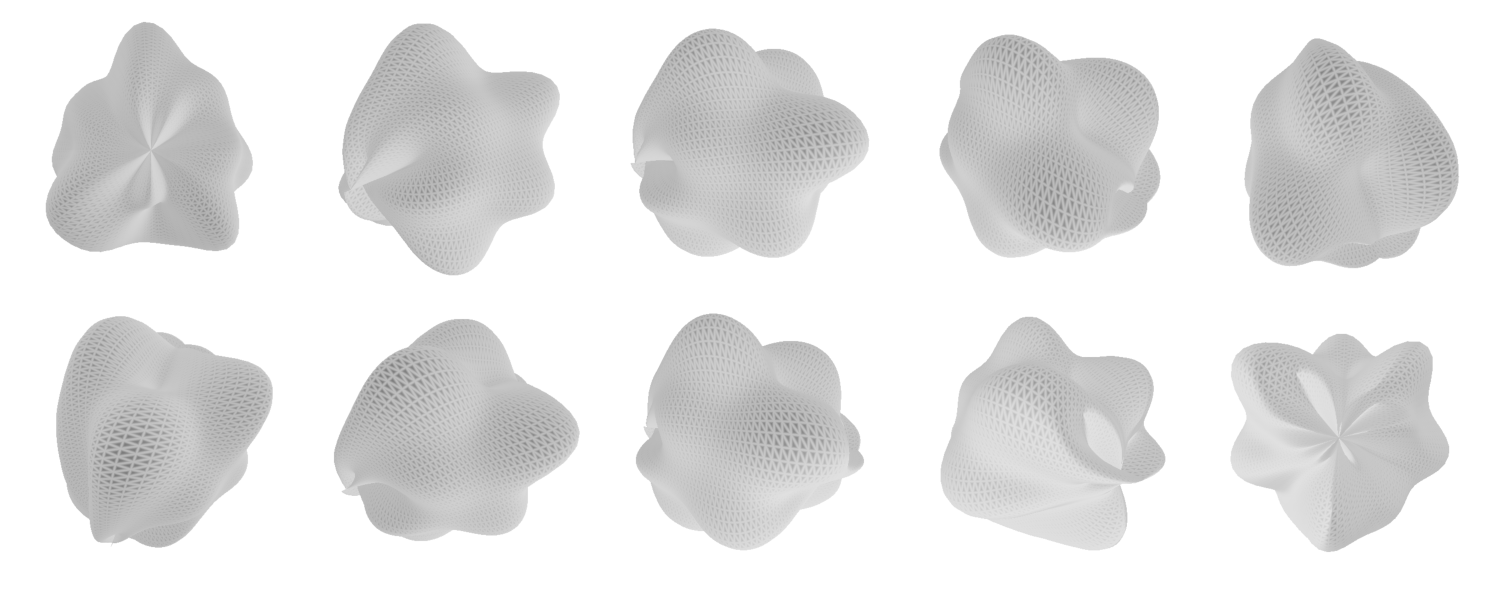


Error Statistics:
  Mean Absolute Error: 0.008694
  Max Absolute Error: 0.585978
  Final Loss (MSE): 0.000477


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.45436272..1.1987097].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.4543415..1.3503461].


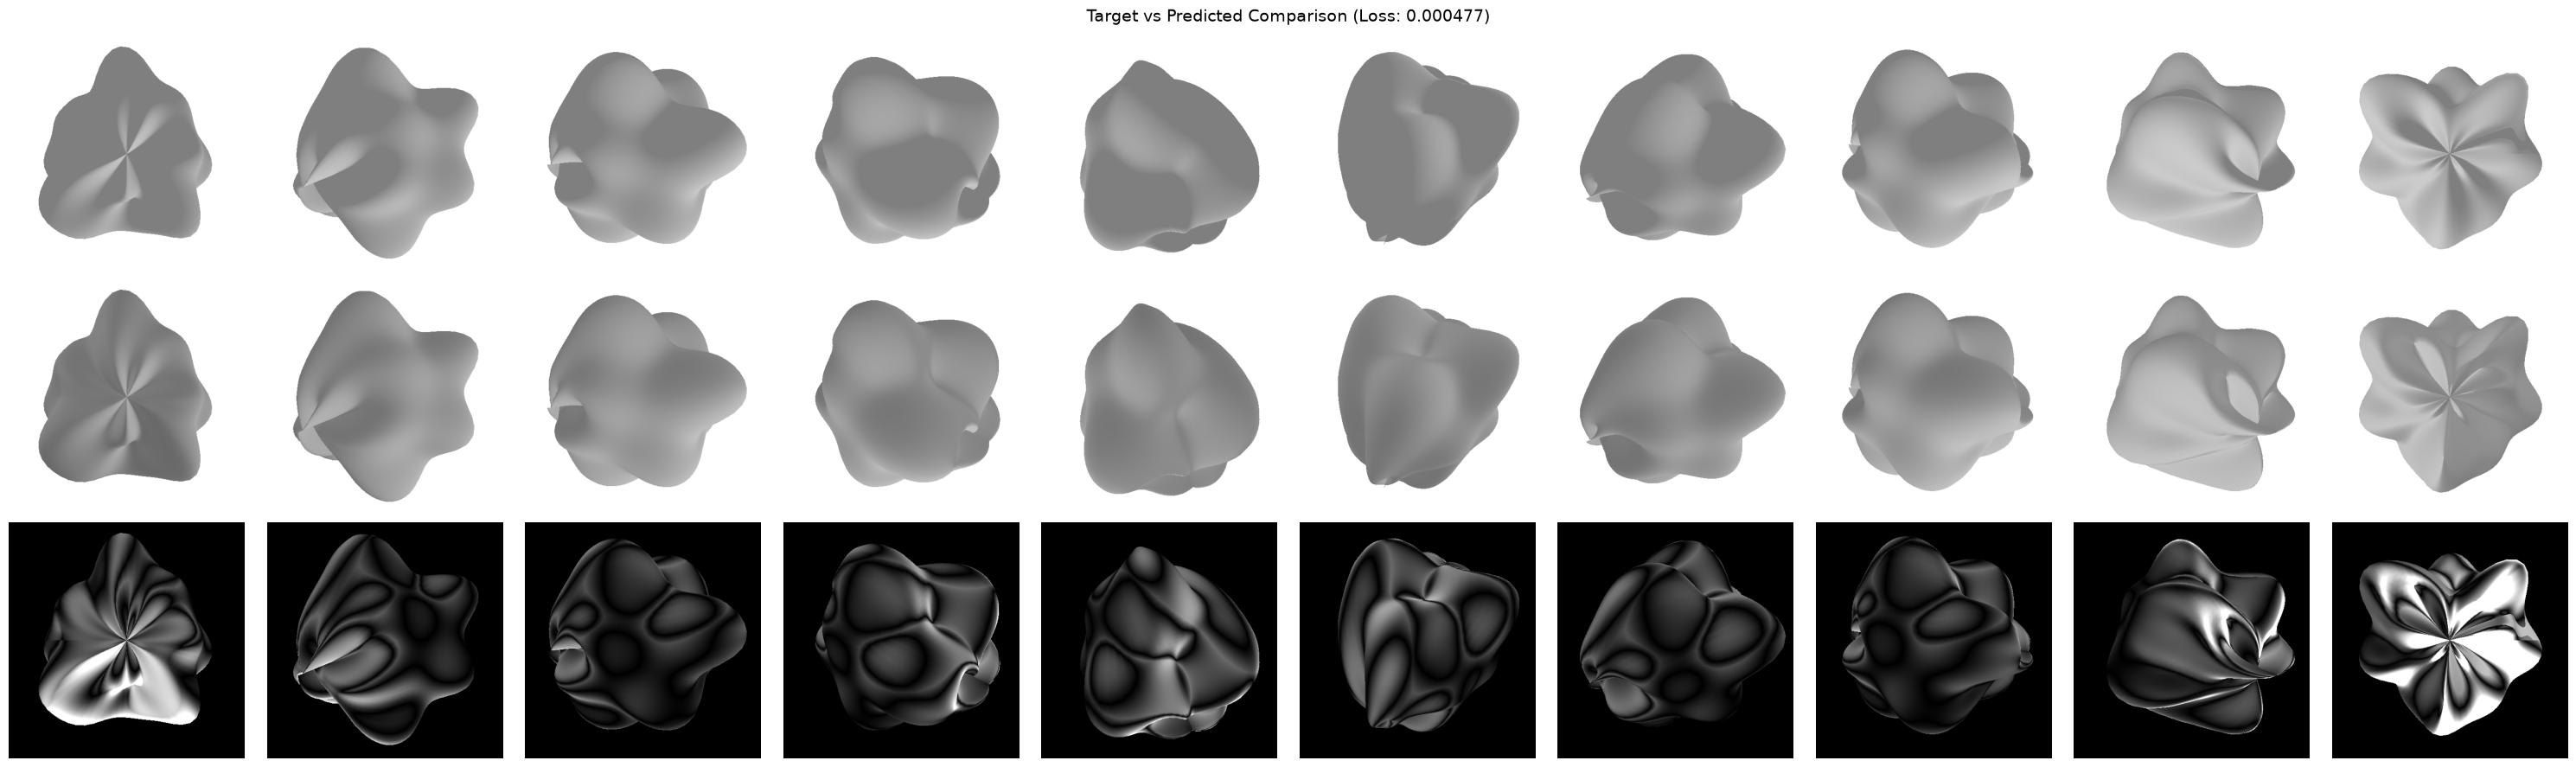

✓ Saved comparison to: ./sh_tutorial_output/comparison.png


In [54]:
# Save predicted images
save_image_grid(pred_images.detach().cpu().numpy(),
               os.path.join(output_dir, "predicted_sh.png"), rows=2, cols=5)

# Compute error statistics
diff_images = torch.abs(pred_images - target_images)
mean_error = diff_images.mean().item()
max_error = diff_images.max().item()

print(f"\nError Statistics:")
print(f"  Mean Absolute Error: {mean_error:.6f}")
print(f"  Max Absolute Error: {max_error:.6f}")
print(f"  Final Loss (MSE): {loss.item():.6f}")

# Create comparison visualization
fig, axes = plt.subplots(3, batch_size, figsize=(batch_size * 3, 9))

for i in range(batch_size):
    # Row 1: Target
    axes[0, i].imshow(target_images[i, ..., :3].cpu().numpy())
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_ylabel('Target\n(PointLight)', fontsize=12, rotation=0, ha='right', va='center')
    
    # Row 2: Predicted
    axes[1, i].imshow(pred_images[i, ..., :3].detach().cpu().numpy())
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_ylabel('Predicted\n(SH)', fontsize=12, rotation=0, ha='right', va='center')
    
    # Row 3: Difference (10x amplified)
    diff_img = diff_images[i, ..., :3].detach().cpu().numpy()
    axes[2, i].imshow(np.clip(diff_img * 10, 0, 1))
    axes[2, i].axis('off')
    if i == 0:
        axes[2, i].set_ylabel('Difference\n(10x)', fontsize=12, rotation=0, ha='right', va='center')

plt.suptitle(f'Target vs Predicted Comparison (Loss: {loss.item():.6f})', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "comparison.png"), dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Saved comparison to: {output_dir}/comparison.png")